# RuleCOSI+ Experimental Grid Search — v3 (sin `recoveries`, CatBoost limpio)

Esta versión constituye el **Escenario B limpio**. A diferencia de la
tesis de Byron Jaramillo et al. y del propio Escenario A de este trabajo, la variable
`recoveries` fue eliminada **antes del entrenamiento de CatBoost** (en la etapa de
preprocesamiento de `main.py`). Por tanto, todos los pickles cargados aquí ya carecen
de esa columna y el modelo CatBoost subyacente nunca la vio durante su entrenamiento.

No se requiere ningún paso de neutralización.

In [2]:
import sys, os, pickle, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

project_root = os.path.dirname(os.path.dirname(os.getcwd()))
vendor_path  = os.path.join(project_root, 'vendor', 'rulecosi')
src_path     = os.path.join(project_root, 'src')
for p in [project_root, vendor_path, src_path]:
    if p not in sys.path: sys.path.insert(0, p)

from config import MODEL_DIR, PKL_DIR
from rulecosi import RuleCOSIClassifier
from src.model.train_model import encode_data_like_training

print(f'project_root : {project_root}')
print(f'PKL_DIR      : {PKL_DIR}')
print(f'MODEL_DIR    : {MODEL_DIR}')

project_root : c:\Users\danli\OneDrive - Universidad San Francisco de Quito\Tesis Danilo\Tesis\Rule reduction\Tesis Byron\Tesis Danilo\01 FUZZY INFERENCE SYSTEM
PKL_DIR      : c:\Users\danli\OneDrive - Universidad San Francisco de Quito\Tesis Danilo\Tesis\Rule reduction\Tesis Byron\Tesis Danilo\01 FUZZY INFERENCE SYSTEM\object\pkl
MODEL_DIR    : c:\Users\danli\OneDrive - Universidad San Francisco de Quito\Tesis Danilo\Tesis\Rule reduction\Tesis Byron\Tesis Danilo\01 FUZZY INFERENCE SYSTEM\object\model


## 1. Carga de datos

In [3]:
def load_pkl(path):
    with open(path,'rb') as f: return pickle.load(f)

X_train_cosi = load_pkl(os.path.join(PKL_DIR,'X_train_cosi.pkl'))
y_train_cosi = load_pkl(os.path.join(PKL_DIR,'y_train_cosi.pkl'))
X_test       = load_pkl(os.path.join(PKL_DIR,'X_test.pkl'))
y_test       = load_pkl(os.path.join(PKL_DIR,'y_test.pkl'))

print(f'X_train_cosi : {X_train_cosi.shape}')
print(f'X_test       : {X_test.shape}')
print(f'Columnas     : {list(X_train_cosi.columns)}')
vc = pd.Series(y_train_cosi).value_counts(normalize=True).round(3)
print(f'Balance: class 0 = {vc[0]*100:.1f}%, class 1 = {vc[1]*100:.1f}%')

X_train_cosi : (391338, 11)
X_test       : (559054, 11)
Columnas     : ['last_fico_range_high', 'term_num', 'fico_range_low', 'total_rec_late_fee', 'acc_open_past_24mths', 'dti', 'mort_acc', 'loan_amnt', 'debt_settlement_flag', 'grade', 'verification_status']
Balance: class 0 = 80.5%, class 1 = 19.5%


## 2. Carga del modelo CatBoost preentrenado

In [4]:
from catboost import CatBoostClassifier

model_files = [f for f in os.listdir(MODEL_DIR)
               if f.startswith('catboost_DANI_encoded') and f.endswith('_model.cbm')]
model_files.sort(reverse=True)
latest_prefix = model_files[0].replace('_model.cbm','')
print(f'Modelo seleccionado: {latest_prefix}')

catboost_model = CatBoostClassifier()
catboost_model.load_model(os.path.join(MODEL_DIR, f'{latest_prefix}_model.cbm'))

with open(os.path.join(MODEL_DIR, f'{latest_prefix}_category_mappings.pkl'),'rb') as f:
    cat_mappings = pickle.load(f)
with open(os.path.join(MODEL_DIR, f'{latest_prefix}_metrics.json'),'r') as f:
    cb_metrics = json.load(f)

cb_f1        = cb_metrics.get('val_f1', cb_metrics.get('f1', None))
cb_threshold = cb_metrics.get('optimal_threshold', 0.5)
F1_THRESHOLD = round(cb_f1 * 0.85, 4)

n_trees     = catboost_model.tree_count_
mp          = catboost_model.get_all_params()
tree_depth  = int(mp.get('depth', mp.get('max_depth', 5)))
n_crisp_max = n_trees * (2 ** tree_depth)

print(f'\nF1 CatBoost (val)  : {cb_f1:.4f}')
print(f'Umbral aceptable   : {F1_THRESHOLD:.4f}  (85% del F1 base)')
print(f'Threshold óptimo   : {cb_threshold}')
print(f'\nEstructura CatBoost:')
print(f'  Árboles            : {n_trees}')
print(f'  Profundidad        : {tree_depth}')
print(f'  Reglas teóricas    : {n_crisp_max:,}  (= {n_trees} x 2^{tree_depth})')

Modelo seleccionado: catboost_DANI_encoded_20260711_024807

F1 CatBoost (val)  : 0.7740
Umbral aceptable   : 0.6579  (85% del F1 base)
Threshold óptimo   : 0.4

Estructura CatBoost:
  Árboles            : 17
  Profundidad        : 5
  Reglas teóricas    : 544  (= 17 x 2^5)


## 3. Encoding de datos

In [5]:
X_train_encoded = encode_data_like_training(X_train_cosi, cat_mappings)
X_test_encoded  = encode_data_like_training(X_test, cat_mappings)

print(f'X_train_encoded : {X_train_encoded.shape}')
print(f'X_test_encoded  : {X_test_encoded.shape}')
print(f'\nTipos de datos (primeras 8 columnas):')
print(X_train_encoded.dtypes.head(8))

X_train_encoded : (391338, 11)
X_test_encoded  : (559054, 11)

Tipos de datos (primeras 8 columnas):
last_fico_range_high    float64
term_num                  int64
fico_range_low          float64
total_rec_late_fee      float64
acc_open_past_24mths    float64
dti                     float64
mort_acc                float64
loan_amnt               float64
dtype: object


## 4. Reglas baseline (sin filtros)

In [6]:
rc_baseline = RuleCOSIClassifier(
    base_ensemble=catboost_model,
    conf_threshold=0.0, cov_threshold=0.0, c=0.999, random_state=42
)
rc_baseline.fit(X_train_encoded, y_train_cosi)

N_RULES_BASELINE = sum(len(rs.rules) for rs in rc_baseline.original_rulesets_)
N_RULES_SIMPLIFIED_BASELINE = len(rc_baseline.simplified_ruleset_.rules)

print(f'Reglas crudas (original_rulesets_)     : {N_RULES_BASELINE}')
print(f'Reglas simplificadas (sin filtros)     : {N_RULES_SIMPLIFIED_BASELINE}')
print(f'Referencia teórica                     : {n_crisp_max:,}')

print('\n=== Reglas del modelo seleccionado ===')
print('\n' + '='*60)
print('REGLAS  EXTRAIDAS')
print('='*60)
for i, rule in enumerate(rc_baseline.simplified_ruleset_.rules):
    print(f'Regla {i+1}: {rule}')

Reglas crudas (original_rulesets_)     : 332
Reglas simplificadas (sin filtros)     : 15
Referencia teórica                     : 544

=== Reglas del modelo seleccionado ===

REGLAS  EXTRAIDAS
Regla 1: (debt_settlement_flag ≤ 0.500) ˄ (fico_range_low > 647.500) ˄ (last_fico_range_high > 681.500) → [0]
Regla 2: (fico_range_low > 647.500) ˄ (last_fico_range_high ≤ 626.500) ˄ (loan_amnt > 8862.500) → [1]
Regla 3: (debt_settlement_flag ≤ 0.500) ˄ (fico_range_low > 647.500) ˄ (last_fico_range_high > 596.500) ˄ (loan_amnt ≤ 14812.500) → [0]
Regla 4: (debt_settlement_flag ≤ 0.500) ˄ (fico_range_low > 647.500) ˄ (last_fico_range_high > 596.500) → [0]
Regla 5: (fico_range_low > 647.500) ˄ (last_fico_range_high ≤ 626.500) → [1]
Regla 6: (debt_settlement_flag > 0.500) ˄ (loan_amnt > 8862.500) → [1]
Regla 7: (debt_settlement_flag > 0.500) ˄ (mort_acc ≤ 2.500) → [1]
Regla 8: (debt_settlement_flag > 0.500) ˄ (dti > 12.905) ˄ (mort_acc > 2.500) → [1]
Regla 9: (debt_settlement_flag ≤ 0.500) ˄ (last_fi

## 5. Grid experimental — 24 configuraciones

In [7]:
param_grid = [
    {'conf_threshold': alpha, 'cov_threshold': beta, 'c': c_val}
    for alpha in [0.50, 0.95]
    for beta  in [0.00, 0.01, 0.10]
    for c_val in [0.01, 0.05, 0.10, 0.25]
]
print(f'Total configuraciones: {len(param_grid)}')
pd.DataFrame(param_grid)

Total configuraciones: 24


,conf_threshold,cov_threshold,c
0,0.50,0.00,0.01
1,0.50,0.00,0.05
2,0.50,0.00,0.10
3,0.50,0.00,0.25
4,0.50,0.01,0.01
5,0.50,0.01,0.05
6,0.50,0.01,0.10
7,0.50,0.01,0.25
8,0.50,0.10,0.01
9,0.50,0.10,0.05


## 6. Ejecución del grid

In [8]:
def evaluar_config(params, catboost_model, X_train, y_train, X_test, y_test,
                   n_rules_baseline, cb_f1, i=None, total=None):
    if i is not None:
        print(f'  [{i+1:2d}/{total}] alpha={params["conf_threshold"]:.2f} '
              f'beta={params["cov_threshold"]:.2f} c={params["c"]:.2f} ...', end=' ')

    rc = RuleCOSIClassifier(base_ensemble=catboost_model, **params, random_state=42)
    rc.fit(X_train, y_train)

    all_rules    = rc.simplified_ruleset_.rules
    active_rules = [r for r in all_rules if len(r.A) > 0]
    n_rules      = len(active_rules)
    avg_cond     = (round(sum(len(r.A) for r in active_rules)/len(active_rules), 2)
                    if active_rules else 0)
    redu = round(1 - n_rules/n_rules_baseline, 4) if n_rules_baseline > 0 else 0

    y_pred = rc.predict(X_test)
    _, _, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='binary', zero_division=0)
    pct_cb = round(f1/cb_f1*100, 1) if cb_f1 > 0 else 0

    if i is not None:
        print(f'n_rules={n_rules:3d}  F1={f1:.4f}  ({pct_cb}% del Cat Boost)')

    return {'conf_threshold': params['conf_threshold'],
            'cov_threshold':  params['cov_threshold'],
            'c':              params['c'],
            'n_rules':        n_rules, 'F1_test': round(f1,4),
            'pct_catboost_f1': pct_cb, 'avg_conditions': avg_cond,
            'REDU': redu, 'cumple_umbral': f1 >= (cb_f1*0.85)}


print('Iniciando grid search (24 configuraciones)...')
print('-'*65)

all_results = [
    evaluar_config(params=params, catboost_model=catboost_model,
                   X_train=X_train_encoded, y_train=y_train_cosi,
                   X_test=X_test_encoded,   y_test=y_test,
                   n_rules_baseline=N_RULES_BASELINE, cb_f1=cb_f1,
                   i=i, total=len(param_grid))
    for i, params in enumerate(param_grid)
]
print('-'*65)
print('Completado.')

Iniciando grid search (24 configuraciones)...
-----------------------------------------------------------------
  [ 1/24] alpha=0.50 beta=0.00 c=0.01 ... n_rules= 15  F1=0.7624  (98.5% del Cat Boost)
  [ 2/24] alpha=0.50 beta=0.00 c=0.05 ... n_rules= 15  F1=0.7624  (98.5% del Cat Boost)
  [ 3/24] alpha=0.50 beta=0.00 c=0.10 ... n_rules= 23  F1=0.7671  (99.1% del Cat Boost)
  [ 4/24] alpha=0.50 beta=0.00 c=0.25 ... n_rules= 22  F1=0.7614  (98.4% del Cat Boost)
  [ 5/24] alpha=0.50 beta=0.01 c=0.01 ... n_rules=  5  F1=0.7652  (98.9% del Cat Boost)
  [ 6/24] alpha=0.50 beta=0.01 c=0.05 ... n_rules=  5  F1=0.7652  (98.9% del Cat Boost)
  [ 7/24] alpha=0.50 beta=0.01 c=0.10 ... n_rules=  5  F1=0.7652  (98.9% del Cat Boost)
  [ 8/24] alpha=0.50 beta=0.01 c=0.25 ... n_rules=  5  F1=0.7652  (98.9% del Cat Boost)
  [ 9/24] alpha=0.50 beta=0.10 c=0.01 ... n_rules=  2  F1=0.7591  (98.1% del Cat Boost)
  [10/24] alpha=0.50 beta=0.10 c=0.05 ... n_rules=  2  F1=0.7591  (98.1% del Cat Boost)
  [11/24

## 7. Tabla de métricas

In [9]:
df_results = pd.DataFrame(all_results).sort_values('n_rules').reset_index(drop=True)

df_display = df_results.copy()
df_display.index = df_display.index + 1
df_display['cumple_umbral'] = df_display['cumple_umbral'].map({True:'SI', False:'NO'})
df_display = df_display.rename(columns={
    'conf_threshold':'alpha','cov_threshold':'beta','c':'c',
    'n_rules':'n_reglas','F1_test':'F1_test','pct_catboost_f1':'% F1_CB',
    'avg_conditions':'avg_cond','REDU':'REDU','cumple_umbral':'>= 85% CB'})

print(f'Umbral F1 minimo : {F1_THRESHOLD:.4f}  (85% de F1_CB={cb_f1:.4f})')
print(f'Configs validas  : {df_results["cumple_umbral"].sum()} / {len(df_results)}')
print()
print(df_display.to_string())

Umbral F1 minimo : 0.6579  (85% de F1_CB=0.7740)
Configs validas  : 12 / 24

    alpha  beta     c  n_reglas  F1_test  % F1_CB  avg_cond    REDU >= 85% CB
1    0.95  0.10  0.01         0   0.0000      0.0      0.00  1.0000        NO
2    0.95  0.10  0.05         0   0.0000      0.0      0.00  1.0000        NO
3    0.95  0.10  0.10         0   0.0000      0.0      0.00  1.0000        NO
4    0.95  0.10  0.25         0   0.0000      0.0      0.00  1.0000        NO
5    0.95  0.00  0.01         1   0.2486     32.1      1.00  0.9970        NO
6    0.95  0.00  0.05         1   0.2486     32.1      1.00  0.9970        NO
7    0.95  0.00  0.10         1   0.2486     32.1      1.00  0.9970        NO
8    0.95  0.00  0.25         1   0.2486     32.1      1.00  0.9970        NO
9    0.95  0.01  0.01         1   0.2486     32.1      1.00  0.9970        NO
10   0.95  0.01  0.05         1   0.2486     32.1      1.00  0.9970        NO
11   0.95  0.01  0.10         1   0.2486     32.1      1.00  0.99

## 8. Gráficos de barras — n_reglas antes vs. después

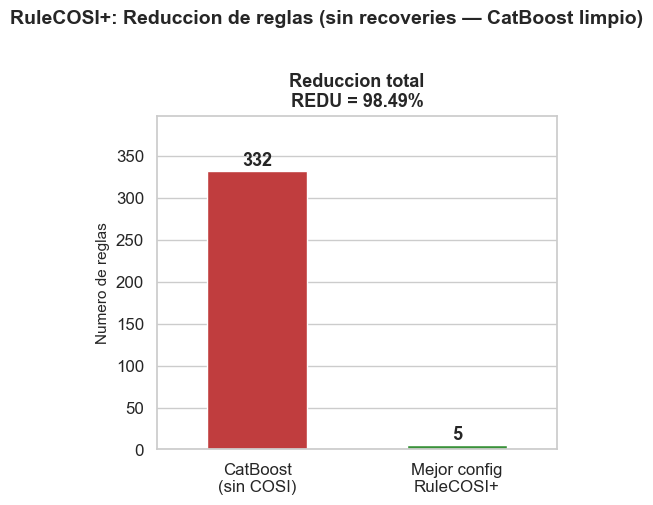

Figura guardada: barras_comparativa_v3.png


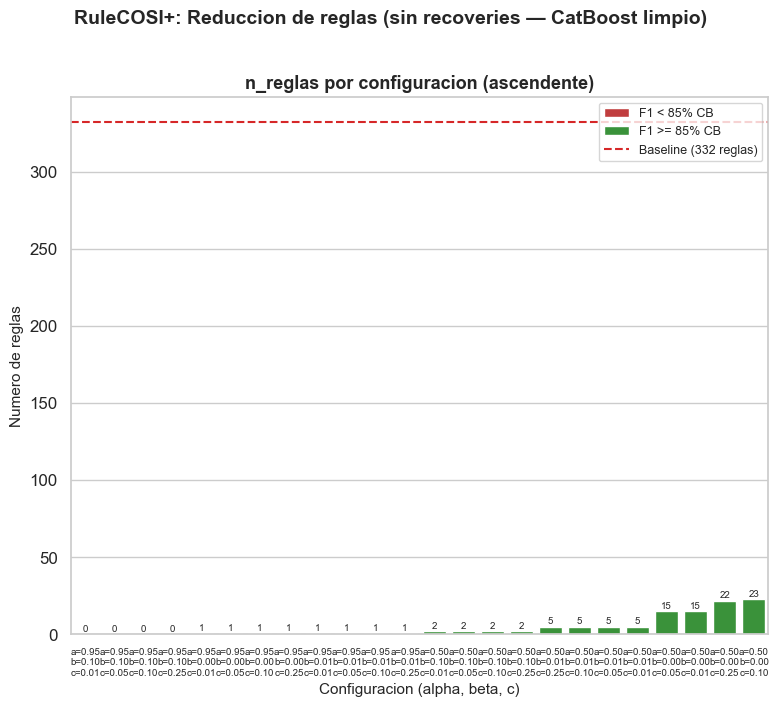

Figura guardada: barras_nreglas_v3.png


In [14]:
#  Reducción total (barra comparativa) ─────────────
fig0, ax0 = plt.subplots(figsize=(5, 5))

best_row = df_results.iloc[17]
df_cmp = pd.DataFrame({
    'Modelo': ['CatBoost\n(sin COSI)', 'Mejor config\nRuleCOSI+'],
    'n_reglas': [N_RULES_BASELINE, best_row['n_rules']],
    'Tipo': ['Baseline', 'RuleCOSI+']
})
sns.barplot(data=df_cmp, x='Modelo', y='n_reglas', hue='Tipo',
            palette={'Baseline':'#d62728','RuleCOSI+':'#2ca02c'},
            ax=ax0, legend=False, width=0.5)
for bar, val in zip(ax0.patches, [N_RULES_BASELINE, best_row['n_rules']]):
    ax0.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=13)
redu_best = round(1 - best_row['n_rules']/N_RULES_BASELINE, 4)
ax0.set_title(f'Reduccion total\nREDU = {redu_best:.2%}', fontsize=13, fontweight='bold')
ax0.set_ylabel('Numero de reglas', fontsize=11)
ax0.set_xlabel('')
ax0.set_ylim(0, N_RULES_BASELINE*1.2)

plt.suptitle('RuleCOSI+: Reduccion de reglas (sin recoveries — CatBoost limpio)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('barras_comparativa_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: barras_comparativa_v3.png')


#  n_reglas por configuración ──────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 7))

df_plot = df_results.sort_values('n_rules').reset_index(drop=True)
df_plot['Config'] = [f"a={r['conf_threshold']:.2f}\nb={r['cov_threshold']:.2f}\nc={r['c']:.2f}"
                     for _,r in df_plot.iterrows()]
df_plot['Estado'] = df_plot['cumple_umbral'].map({True:'F1 >= 85% CB',False:'F1 < 85% CB'})

bp = sns.barplot(data=df_plot, x='Config', y='n_rules', hue='Estado',
                 palette={'F1 >= 85% CB':'#2ca02c','F1 < 85% CB':'#d62728'},
                 ax=ax1, dodge=False)
for bar, val in zip(bp.patches, df_plot['n_rules']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             str(val), ha='center', va='bottom', fontsize=7)
ax1.axhline(N_RULES_BASELINE, color='#d62728', linestyle='--', linewidth=1.5,
            label=f'Baseline ({N_RULES_BASELINE:,} reglas)')
ax1.set_title('n_reglas por configuracion (ascendente)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Numero de reglas', fontsize=11)
ax1.set_xlabel('Configuracion (alpha, beta, c)', fontsize=11)
ax1.tick_params(axis='x', labelsize=7)
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles=handles, labels=labels, fontsize=9, loc='upper right')

plt.suptitle('RuleCOSI+: Reduccion de reglas (sin recoveries — CatBoost limpio)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('barras_nreglas_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: barras_nreglas_v3.png')

## 9. Heatmaps de métricas

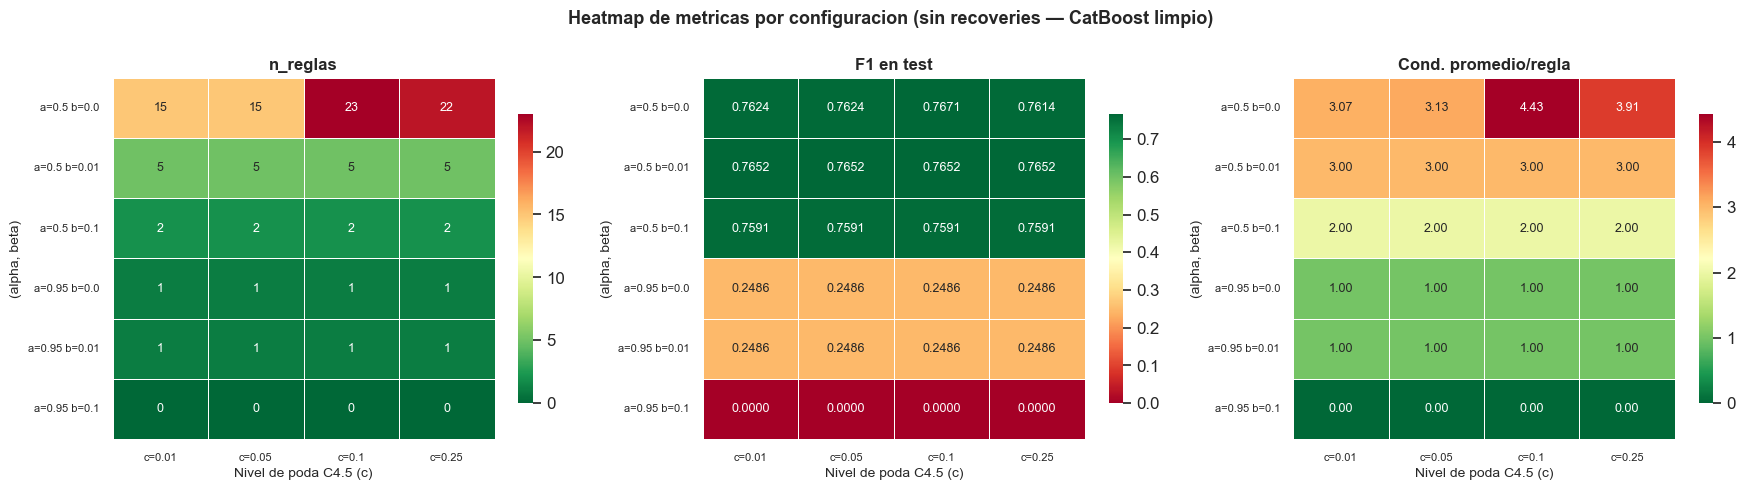

Figura guardada: heatmap_metricas_v3.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, title, cmap, fmt) in zip(axes, [
    ('n_rules',        'n_reglas',             'RdYlGn_r', '.0f'),
    ('F1_test',        'F1 en test',           'RdYlGn',   '.4f'),
    ('avg_conditions', 'Cond. promedio/regla', 'RdYlGn_r', '.2f'),
]):
    pivot = df_results.pivot_table(
        index=['conf_threshold','cov_threshold'], columns='c',
        values=col, aggfunc='first'
    )
    pivot.index = [f'a={a} b={b}' for a,b in pivot.index]
    pivot.columns = [f'c={v}' for v in pivot.columns]

    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, ax=ax,
                linewidths=0.5, linecolor='white',
                cbar_kws={'shrink':0.8}, annot_kws={'size':9})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Nivel de poda C4.5 (c)', fontsize=10)
    ax.set_ylabel('(alpha, beta)', fontsize=10)
    ax.tick_params(labelsize=8)

plt.suptitle('Heatmap de metricas por configuracion (sin recoveries — CatBoost limpio)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_metricas_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: heatmap_metricas_v3.png')

## 10. Frontera de Pareto: F1 vs. n_reglas

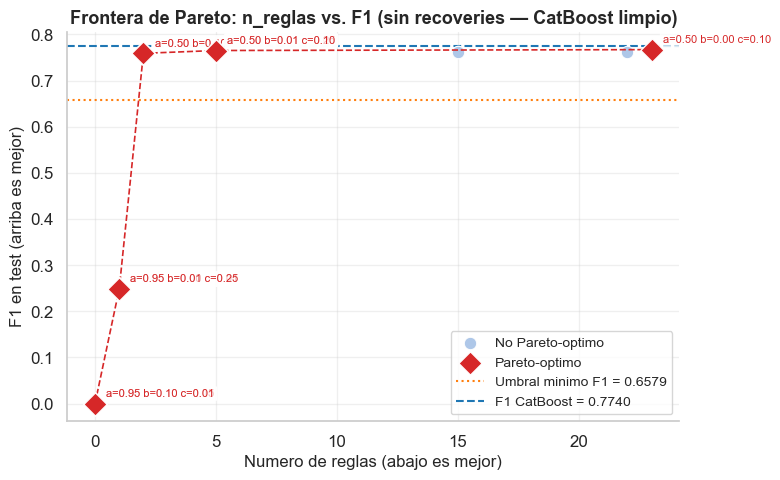


Puntos Pareto-optimos: 21
 conf_threshold  cov_threshold    c  n_rules  F1_test  avg_conditions   REDU
           0.95           0.10 0.25        0   0.0000            0.00 1.0000
           0.95           0.10 0.10        0   0.0000            0.00 1.0000
           0.95           0.10 0.05        0   0.0000            0.00 1.0000
           0.95           0.10 0.01        0   0.0000            0.00 1.0000
           0.95           0.00 0.25        1   0.2486            1.00 0.9970
           0.95           0.01 0.10        1   0.2486            1.00 0.9970
           0.95           0.01 0.01        1   0.2486            1.00 0.9970
           0.95           0.01 0.05        1   0.2486            1.00 0.9970
           0.95           0.00 0.05        1   0.2486            1.00 0.9970
           0.95           0.00 0.10        1   0.2486            1.00 0.9970
           0.95           0.00 0.01        1   0.2486            1.00 0.9970
           0.95           0.01 0.25        1   0.

In [15]:
def es_pareto_optimo(costs):
    is_pareto = np.ones(len(costs), dtype=bool)
    for i, c in enumerate(costs):
        if is_pareto[i]:
            dominated = np.all(c<=costs,axis=1) & np.any(c<costs,axis=1)
            is_pareto[dominated] = False
    return is_pareto

costs  = np.array([[r['n_rules'],-r['F1_test']] for r in all_results])
pareto = es_pareto_optimo(costs)

df_pareto_plot = pd.DataFrame(all_results)
df_pareto_plot['Tipo'] = ['Pareto-optimo' if p else 'No optimo' for p in pareto]
df_pareto_plot['label'] = [
    f"a={r['conf_threshold']:.2f} b={r['cov_threshold']:.2f} c={r['c']:.2f}"
    for r in all_results]

fig, ax = plt.subplots(figsize=(8,5))

sns.scatterplot(
    data=df_pareto_plot[df_pareto_plot['Tipo']=='No optimo'],
    x='n_rules', y='F1_test', color='#aec7e8', s=80,
    label='No Pareto-optimo', ax=ax, zorder=3)

sns.scatterplot(
    data=df_pareto_plot[df_pareto_plot['Tipo']=='Pareto-optimo'],
    x='n_rules', y='F1_test', color='#d62728', s=140,
    marker='D', label='Pareto-optimo', ax=ax, zorder=5)

pareto_pts = df_pareto_plot[df_pareto_plot['Tipo']=='Pareto-optimo'].sort_values('n_rules')
ax.plot(pareto_pts['n_rules'], pareto_pts['F1_test'],
        color='#d62728', linestyle='--', linewidth=1.2, zorder=4)

for _,row in pareto_pts.iterrows():
    ax.annotate(row['label'], xy=(row['n_rules'],row['F1_test']),
                xytext=(8,5), textcoords='offset points', fontsize=8,
                color='#d62728',
                bbox=dict(boxstyle='round,pad=0.2',fc='white',alpha=0.7))

ax.axhline(F1_THRESHOLD, color='#ff7f0e', linestyle=':', linewidth=1.5,
           label=f'Umbral minimo F1 = {F1_THRESHOLD:.4f}')
ax.axhline(cb_f1, color='#1f77b4', linestyle='--', linewidth=1.5,
           label=f'F1 CatBoost = {cb_f1:.4f}')

ax.set_xlabel('Numero de reglas (abajo es mejor)', fontsize=12)
ax.set_ylabel('F1 en test (arriba es mejor)', fontsize=12)
ax.set_title('Frontera de Pareto: n_reglas vs. F1 (sin recoveries — CatBoost limpio)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('pareto_cosi_v3.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nPuntos Pareto-optimos: {sum(pareto)}')
df_p = df_pareto_plot[df_pareto_plot['Tipo']=='Pareto-optimo'].sort_values('n_rules')
print(df_p[['conf_threshold','cov_threshold','c','n_rules','F1_test','avg_conditions','REDU']].to_string(index=False))

## 11. Selección de la configuración final

In [13]:
candidatos = [r for r,p in zip(all_results,pareto) if p and r['cumple_umbral']]
if not candidatos:
    print(' Ningun punto Pareto-optimo cumple el umbral. Relajando criterio.')
    candidatos = [r for r,p in zip(all_results,pareto) if p]

# Se elige el punto inmediatamente por encima del codo de Pareto (α=0.50, β=0.01, c=0.10).
# El codo está en 2 reglas (F1=0.7591, 98.1 % del baseline). Subir a 5 reglas recupera
# 0.0061 de F1 adicional (98.9 % del baseline) a cambio de solo 3 reglas más.
# El tramo siguiente (5 → 23 reglas) solo aporta 0.0019 de F1 con 18 reglas adicionales:
# la ganancia marginal cae un 95 %. El punto seleccionado ofrece el mejor equilibrio
# entre compresión e interpretabilidad dentro de la frontera de Pareto.
best_config = next(r for r in candidatos
                   if r['conf_threshold'] == 0.50
                   and r['cov_threshold'] == 0.01
                   and r['c'] == 0.10)

print('='*55)
print('  CONFIGURACION SELECCIONADA (sin recoveries — CatBoost limpio)')
print('='*55)
for k,v in best_config.items(): print(f'  {k:<22}: {v}')
print('='*55)

final_rc = RuleCOSIClassifier(
    base_ensemble=catboost_model,
    conf_threshold=best_config['conf_threshold'],
    cov_threshold=best_config['cov_threshold'],
    c=best_config['c'], random_state=42)
final_rc.fit(X_train_encoded, y_train_cosi)


print('\n=== Reglas del modelo seleccionado ===')
print('\n' + '='*60)
print('REGLAS FINALES EXTRAIDAS')
print('='*60)
for i, rule in enumerate(final_rc.simplified_ruleset_.rules):
    print(f'Regla {i+1}: {rule}')


print('\n=== Métricas de las Reglas del modelo seleccionado ===')
for i,rule in enumerate(final_rc.simplified_ruleset_.rules):
    tag = 'DEFAULT' if len(rule.A)==0 else ''
    print(f'\nRegla {i} {tag}')
    print(f'  Condiciones : {rule.A}')
    print(f'  Clase pred. : {rule.class_index}')
    print(f'  Confianza   : {rule.conf:.4f}')
    print(f'  Cobertura   : {rule.cov:.4f}')

  CONFIGURACION SELECCIONADA (sin recoveries — CatBoost limpio)
  conf_threshold        : 0.5
  cov_threshold         : 0.01
  c                     : 0.1
  n_rules               : 5
  F1_test               : 0.7652
  pct_catboost_f1       : 98.9
  avg_conditions        : 3.0
  REDU                  : 0.9849
  cumple_umbral         : True

=== Reglas del modelo seleccionado ===

REGLAS FINALES EXTRAIDAS
Regla 1: (debt_settlement_flag ≤ 0.500) ˄ (fico_range_low > 647.500) ˄ (last_fico_range_high > 681.500) → [0]
Regla 2: (fico_range_low > 647.500) ˄ (last_fico_range_high ≤ 626.500) ˄ (loan_amnt > 8862.500) → [1]
Regla 3: (debt_settlement_flag ≤ 0.500) ˄ (fico_range_low > 647.500) ˄ (last_fico_range_high > 596.500) ˄ (loan_amnt ≤ 14812.500) → [0]
Regla 4: (debt_settlement_flag ≤ 0.500) ˄ (fico_range_low > 647.500) ˄ (last_fico_range_high > 596.500) → [0]
Regla 5: (fico_range_low > 647.500) ˄ (last_fico_range_high ≤ 626.500) → [1]
Regla 6: ( ) → [1]

=== Métricas de las Reglas del modelo 